Quanitfy the difference between two ShakeMaps. To be run in env `shakemap`


## sm_compare update

<Figure size 800x400 with 0 Axes>

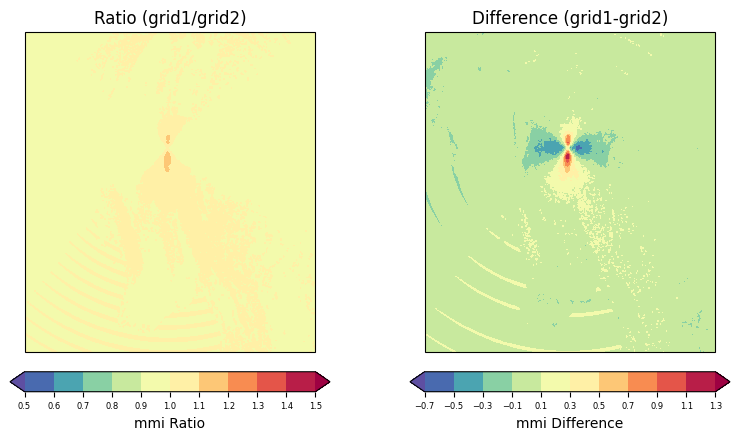

In [ ]:
#!/usr/bin/env python
"""
Compare two shakemaps.
"""

import argparse

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from mapio.shake import ShakeGrid

mag = 7.0
depth = 10
# type = 'constrained'

# Constrained
grid1 = f'/Users/hyin/shakemap_profiles/default/data/synth-ss_us7000pn9s/M{mag}_{depth}km_constrained/products/grid.xml'
# Unconstrained
grid2 = f'/Users/hyin/shakemap_profiles/default/data/synth-ss_us7000pn9s/M{mag}_{depth}km_unconstrained/products/grid.xml'
imt = 'mmi'
nocoasts='False'
output = f'/Users/hyin/usgs_mendenhall/ffsimmer/catalog/synthetic-catalog/M{mag}_{depth}km_comparison'

g1 = ShakeGrid.load(grid1).getData()[imt]
g2 = ShakeGrid.load(grid2).getData()[imt]

g1_geodict = g1.getGeoDict()
g2_geodict = g2.getGeoDict()


try:
    cutdict = g1_geodict.getBoundsWithin(g2_geodict)
except Exception:
    cutdict = g2_geodict.getBoundsWithin(g1_geodict)

# c1 and c2 are grid objects
c1 = g1.interpolateToGrid(cutdict)
c2 = g2.interpolateToGrid(cutdict)

# a1 and a2 are array objects
a1 = c1.getData()
a2 = c2.getData()
ratio = a1 / a2
dif = a1 - a2
lats = np.linspace(cutdict.ymin, cutdict.ymax, ratio.shape[0])
lons = np.linspace(cutdict.xmin, cutdict.xmax, ratio.shape[1])

SIZE = (8, 4)
fig = plt.figure(figsize=SIZE)
wid = 0.4
height = 0.8

# Ratio plot
levels = list(np.linspace(0.5, 1.5, 11))
cmap = plt.cm.Spectral_r
x1 = 0.05
y1 = 0.2

fig = plt.figure(figsize=SIZE)
ax1 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
cs1 = ax1.contourf(lons, lats, np.flipud(ratio), levels, cmap=cmap, extend="both")
if not nocoasts:
    ax1.add_feature(cfeature.COASTLINE)

ax_cbar1 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar1 = fig.colorbar(cs1, cax=ax_cbar1, orientation="horizontal", ticks=levels)
cbar1.ax.tick_params(labelsize=6)
cbar1.ax.set_xlabel(f"{imt} Ratio")
cbar1.ax.get_yaxis().labelpad = 15

# Difference plot
dif_min = np.min(dif)
dif_max = np.max(dif)
if dif_min != dif_max:
    levels = list(np.linspace(dif_min, dif_max, 11))
else:
    levels = list(np.linspace(-10, 10, 11))
x1 = 0.55

ax2 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
cs2 = ax2.contourf(lons, lats, np.flipud(dif), levels, cmap=cmap, extend="both")
if not nocoasts:
    ax2.add_feature(cfeature.COASTLINE)

ax_cbar2 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar2 = fig.colorbar(cs2, cax=ax_cbar2, orientation="horizontal", ticks=levels)
cbar2.ax.tick_params(labelsize=6)
if imt == "pgv":
    cbar2.ax.set_xlabel(f"{imt} Difference (cm/s)")
elif imt == "stdpgv":
    cbar2.ax.set_xlabel(f"{imt} Difference (ln(cm/s))")
elif imt == "mmi" or imt == "stdmmi":
    cbar2.ax.set_xlabel(f"{imt} Difference")
elif "std" in imt:
    cbar2.ax.set_xlabel(f"{imt} Difference (ln(g))")
else:
    cbar2.ax.set_xlabel(f"{imt} Difference (percent g)")
cbar2.ax.get_yaxis().labelpad = 15

ax1.title.set_text('Ratio (grid1/grid2)')
ax2.title.set_text('Difference (grid1-grid2)')

plt.savefig(f"{output}.png", dpi=300, bbox_inches="tight")

# if __name__ == "__main__":
#     main()


## Plot differences with a threshold

In [18]:
import numpy as np

# MMI threshold that we'd like to plot and compare
threshold = 4.3

# Extract numeric arrays from the interpolated GridField objects
a1_cut = c1.getData()
a2_cut = c2.getData()

# Sanity check: shapes must match after interpolateToGrid
assert a1_cut.shape == a2_cut.shape, f"Grid shapes differ: {a1_cut.shape} vs {a2_cut.shape}"

# Build a shared mask where BOTH grids are < 4
shared_mask = (a1 < threshold) & (a2 < threshold)

# Set those pixels to NaN in BOTH arrays so they align
a1_cut[shared_mask] = np.nan
a2_cut[shared_mask] = np.nan

# (Optional) If you compute differences, NaNs will line up and propagate:
diff_cut = a1_cut - a2_cut  # will be NaN anywhere shared_mask is True (and anywhere either was NaN)
rms_cut = np.sqrt((a1_cut - a2_cut)**2)

rms = np.sqrt(np.nanmean(diff_cut**2))


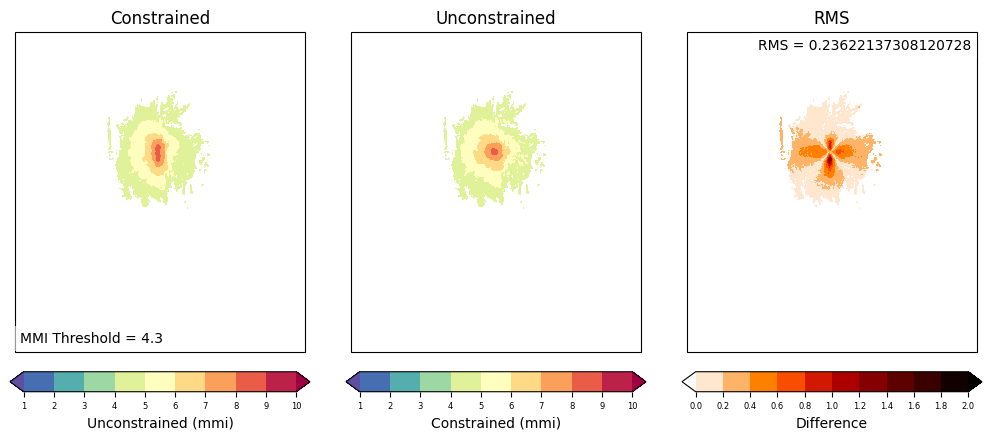

In [20]:
SIZE = (12, 4)
fig = plt.figure(figsize=SIZE)
wid = 0.25
height = 0.8

# Set up contour levels
levels = list(np.linspace(1, 10, 10))
cmap = plt.cm.Spectral_r

## Plot Constrained ShakeMap
# Set axis location
x1 = 0.05
y1 = 0.2
ax1 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
cs1 = ax1.contourf(lons, lats, np.flipud(a1_cut), levels, cmap=cmap, extend="both")
ax_cbar1 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar1 = fig.colorbar(cs1, cax=ax_cbar1, orientation="horizontal", ticks=levels)
cbar1.ax.tick_params(labelsize=6)
cbar1.ax.set_xlabel(f"Unconstrained ({imt})")
ax1.text(
    0.02, 0.02,          # x, y in axes coordinates
    f"MMI Threshold = {threshold}",
    transform=ax1.transAxes,
    ha="left", va="bottom",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

## Plot Unconstrained ShakeMap
x1 = 0.33
ax2 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
cs2 = ax2.contourf(lons, lats, np.flipud(a2_cut), levels, cmap=cmap, extend="both")
ax_cbar2 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar2 = fig.colorbar(cs2, cax=ax_cbar2, orientation="horizontal", ticks=levels)
cbar2.ax.tick_params(labelsize=6)
cbar2.ax.set_xlabel(f"Constrained ({imt})")

# Set up contour levels
levels = list(np.linspace(0, 2.0, 11))
# cmap = plt.cm.magma_r
cmap = plt.cm.gist_heat_r

# Plot Difference
x1 = 0.61
y1 = 0.2
ax3 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
cs3 = ax3.contourf(lons, lats, np.flipud(rms_cut), levels, cmap=cmap, extend="both")
ax_cbar3 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar3 = fig.colorbar(cs3, cax=ax_cbar3, orientation="horizontal", ticks=levels)
cbar3.ax.tick_params(labelsize=6)
cbar3.ax.set_xlabel(f"Difference")

ax3.text(
    0.98, 0.98,          # x, y in axes coordinates
    f"RMS = {rms}",
    transform=ax3.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

ax1.set_title("Constrained")
ax2.set_title("Unconstrained")
ax3.set_title("RMS")

plt.savefig(f"{output}_rms.png", dpi=300, bbox_inches="tight")



## Exceedance curves

In [156]:
import numpy as np
import matplotlib.pyplot as plt

def geodict_bounds(gd):
    """
    Extract xmin, xmax, ymin, ymax, dx, dy from a GeoDict-like object or dict.
    Tries attributes first, falls back to dict keys.
    """
    def get(obj, name, alt=None):
        if hasattr(obj, name):
            return getattr(obj, name)
        if alt is not None and name in obj:
            return obj[name]
        # try common alternatives
        alts = {'xmin':['minx','x_min'], 'xmax':['maxx','x_max'],
                'ymin':['miny','y_min'], 'ymax':['maxy','y_max'],
                'dx':['xdim','xres'], 'dy':['ydim','yres']}
        for k in alts.get(name, []):
            if hasattr(obj, k): return getattr(obj, k)
            if isinstance(obj, dict) and k in obj: return obj[k]
        raise AttributeError(f"Could not find {name} in GeoDict")
    xmin = get(gd, 'xmin')
    xmax = get(gd, 'xmax')
    ymin = get(gd, 'ymin')
    ymax = get(gd, 'ymax')
    dx   = get(gd, 'dx')
    dy   = get(gd, 'dy')
    return xmin, xmax, ymin, ymax, dx, dy

def pixel_area_grid_latlon(shape, gd):
    """
    Approximate per-pixel area (km^2) for an evenly spaced lon/lat raster.
    Assumes PlateCarree (degrees). Area varies with latitude: ~ R^2 * dlon_rad * dlat_rad * cos(lat).
    Returns 2D array of areas matching 'shape'.
    """
    R = 6371.0  # Earth radius in km
    xmin, xmax, ymin, ymax, dx, dy = geodict_bounds(gd)
    ny, nx = shape

    # Build latitude centers from bounds; confirm orientation matches array indexing.
    # Many ShakeMap arrays are displayed origin='lower'. Here we create latitudes from bottom (ymin) to top (ymax).
    lats = np.linspace(ymin + dy/2, ymax - dy/2, ny)  # center of each row
    dlat = np.deg2rad(dy)
    dlon = np.deg2rad(dx)

    # area per row (km^2 per pixel), broadcast to full grid
    row_area = (R * dlat) * (R * dlon) * np.cos(np.deg2rad(lats))  # shape (ny,)
    return np.broadcast_to(row_area[:, None], (ny, nx))  # shape (ny, nx)

def exceedance_area(arr, thresholds, area_grid):
    """
    Area exceedance for array 'arr' at given thresholds.
    Returns area_km2 (per threshold), area_fraction (per threshold), total_area_km2.
    """
    # Handle MaskedArray -> NaN
    data = arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr
    finite = np.isfinite(data)
    total_area = area_grid[finite].sum()
    areas = np.array([area_grid[finite & (data >= t)].sum() for t in thresholds], dtype=float)
    fracs = areas / total_area if total_area > 0 else np.zeros_like(areas)
    return areas, fracs, total_area

# --- Use with your existing objects ---
# After you’ve created c1, c2, and applied your shared NaN mask to a1_cut/a2_cut:
gd = c1.getGeoDict()
area_grid = pixel_area_grid_latlon(a1.shape, gd)

thresholds = np.arange(1.0, 10.01, 0.5)  # choose integer thresholds if preferred

a1_area, a1_frac, a1_total = exceedance_area(a1, thresholds, area_grid)
a2_area, a2_frac, a2_total = exceedance_area(a2, thresholds, area_grid)

print(f"Total valid area (Constrained):   {a1_total:.1f} km²")
print(f"Total valid area (Unconstrained): {a2_total:.1f} km²")

# Plot area fractions (complementary CDF)
fig, ax = plt.subplots(figsize=(7,5))
ax.step(thresholds, a1_frac, where='post', label='Constrained', color='C0')
ax.step(thresholds, a2_frac, where='post', label='Unconstrained', color='C1')
ax.set_xlabel('MMI threshold (t)')
ax.set_ylabel('Area fraction with MMI ≥ t')
ax.set_title('Area-weighted exceedance (MMI)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('MMI_exceedance_area_fraction.png', dpi=200)
plt.close(fig)

Total valid area (Constrained):   98106.8 km²
Total valid area (Unconstrained): 98106.8 km²
